## 中カテゴリあたり固有名詞の数をカウント
- 初期化用vec(平均vec)の作成と、架空の概念に割り当てる固有名詞を、各カテゴリあたり何個ずつ用意できるかの目安を得るために、Wikipediaの各カテゴリに属する固有名詞の数をカウントする。

In [1]:
import pandas as pd
import json
import os

delete_list = ["year"] # year は、すべて2001, 2020, 2231 のような年の数字のみだったため削除。

whole_df = pd.DataFrame()
for filename in os.listdir("../data/dbpedia/wikidata_Things_childs_LIMIT1000"):
    if filename.replace(".csv", "") in delete_list:
        # 削除対象のカテゴリは読み込まない
        continue
    if filename.endswith(".csv"):
        df = pd.read_csv(os.path.join("../data/dbpedia/wikidata_Things_childs_LIMIT1000", filename))
        whole_df = pd.concat([whole_df, df], ignore_index=True)
print(f"Total proper nouns collected: {len(whole_df)}")
whole_df.head()

Total proper nouns collected: 159013


,qid,label,class_label,class_qid
0,Q137919338,Colombian National Cross-Country Skiing,swimmer,Q10843402
1,Q12512,St. Peter's Basilica,church,Q16970
2,Q48435,Basilica and Expiatory Church of the Holy Family,church,Q16970
3,Q5933,Westminster Abbey,church,Q16970
4,Q2943,Sistine Chapel,church,Q16970


In [ ]:
# labelが複数のclass_labelに属していないか確認. subclassのsubclassを取っているものもあるため、上位のsubclassとその下位のsubclassの両方に同じ固有名詞が属している心配がある。
label_class_label_dict = {}
for index, row in whole_df.iterrows():
    label = row['label']
    class_label = row['class_label']
    if label not in label_class_label_dict:
        label_class_label_dict[label] = set()
    label_class_label_dict[label].add(class_label)

# labelが複数のclass_labelに属しているか確認
count = 0
for label, class_labels in label_class_label_dict.items():
    if len(class_labels) > 1:
        print(f"Label: {label}, Class Labels: {class_labels}")
        count += 1
print(f"Number of labels belonging to multiple class labels: {count}")


In [ ]:
# 複数行に同じlabelがある場合は、そのlabelの行を削除する
# whole_filtered_df 
whole_df = whole_df.drop_duplicates(subset=['label'], keep=False)
# print(f"Total proper nouns after removing duplicates: {len(whole_filtered_df)}")
print(f"Total proper nouns after removing duplicates: {len(whole_df)}")

Total proper nouns after removing duplicates: 124164


In [ ]:

# 中カテゴリごとの固有名詞の数をカウントし、dfにする
category_count_df = whole_df.groupby("class_label").size().reset_index(name="count")
category_count_df


,class_label,count
0,Algorithm,419
1,Archive,366
2,Band,939
3,Biomolecule,7
4,Chief,5
...,...,...
235,weapon,262
236,wine,168
237,winery,623
238,written work,909


In [ ]:
print(whole_df[whole_df['class_label'] == 'year']['label'].tolist())

[]


In [ ]:
category_count_df['class_label'].tolist()

['Algorithm',
 'Archive',
 'Band',
 'Biomolecule',
 'Chief',
 'Disease',
 'Election',
 'Employer',
 'EthnicGroup',
 'Flag',
 'Food',
 'Historical region',
 'Intercommunality',
 'Lawyer',
 'Legal Case',
 'Media',
 'Medicine',
 'Mill',
 'Nobel Prize',
 'Noble family',
 'Nuclear Power plant',
 'Ocean',
 'Painting',
 'Port',
 'Producer',
 'PublicService',
 'Pyramid',
 'Site of Special Scientific Interest',
 'Water tower',
 'Watermill',
 'Wikimedia template',
 'Windmill',
 'academic conference',
 'academic subject',
 'activity',
 'agent',
 'aircraft',
 'airline',
 'airport',
 'album',
 'anatomical structure',
 'animal',
 'archipelago',
 'artery',
 'artist',
 'artwork',
 'asteroid',
 'award',
 'baseball league',
 'battery',
 'beer',
 'board game',
 'bone',
 'book',
 'bridge',
 'broadcast network',
 'broadcaster',
 'brown dwarf',
 'building',
 'card game',
 'casino',
 'castle',
 'cat',
 'cave',
 'cemetery',
 'chemical compound',
 'church',
 'city',
 'company',
 'constellation',
 'contest',
 '

In [ ]:
whole_df[whole_df["class_label"] == "factory"]["label"].tolist()

['Humberstone and Santa Laura Saltpeter Works',
 'Tsingtao Brewery',
 'Hoegaarden Brewery',
 'Blohm+Voss',
 'Paulaner Brewery',
 'Meyer Werft',
 'Gdańsk Shipyard',
 'Howaldtswerke-Deutsche Werft',
 'Natanz nuclear facility',
 'Budweiser Budvar',
 'Valmet',
 'Rjukan–Notodden Industrial Heritage Site',
 'Els Quatre Gats',
 'Baltika Breweries',
 'Giga Nevada',
 "Chantiers de l'Atlantique",
 'BrewDog',
 'Erdinger',
 'Miller Brewing Company',
 "Beck's",
 'Westvleteren Brewery',
 'Israel Shipyards Industries Ltd',
 'Royal Mint',
 'Bath Iron Works',
 'Newport News Shipbuilding',
 'Bruichladdich Distillery',
 'Bunnahabhain Distillery',
 'Mythos Beer',
 'Royal Copenhagen',
 'Friedrich Krupp Germaniawerft',
 'A. Le Coq',
 'Hanwha Ocean',
 'Löwenbräu Brewery',
 'Ingalls Shipbuilding',
 'Kremnica Mint',
 'Krombacher Brauerei',
 'Washington Navy Yard',
 'Sumitomo Heavy Industries',
 'Philadelphia Naval Shipyard',
 'Peroni Brewery',
 'Samsung Heavy Industries',
 'Bitburger brewery',
 'Sapporo Brewer

In [ ]:
# propnoun_num_threshold 以上の固有名詞があるカテゴリを抽出する
# propnoun_num_threshold = 200 # 150
propnoun_num_for_init_vec = 100 # 1カテゴリあたりで、初期化vec(平均vec)の作成に使う概念数
propnoun_num_for_new_concept = 50 # 1カテゴリあたりで、新規概念の元にする概念数
propnoun_num_threshold = propnoun_num_for_init_vec + propnoun_num_for_new_concept
filtered_category_count_df = category_count_df[category_count_df["count"] >= propnoun_num_threshold]
print(f"{propnoun_num_threshold}以上の固有名詞があるカテゴリの数: {filtered_category_count_df.shape[0]}")
filtered_category_count_df

130以上の固有名詞があるカテゴリの数: 163


,class_label,count
0,Algorithm,419
1,Archive,366
2,Band,939
6,Election,994
10,Food,985
...,...,...
235,weapon,262
236,wine,168
237,winery,623
238,written work,909


In [13]:
print(filtered_category_count_df['class_label'].tolist())

['Band', 'Disease', 'Election', 'EthnicGroup', 'Flag', 'Food', 'Legal Case', 'Media', 'Noble family', 'PublicService', 'Site of Special Scientific Interest', 'Wikimedia template', 'academic subject', 'activity', 'agent', 'aircraft', 'airport', 'album', 'animal', 'artwork', 'award', 'book', 'bridge', 'broadcaster', 'building', 'card game', 'castle', 'cemetery', 'church', 'city', 'company', 'contest', 'cycling race', 'dam', 'deity', 'disease', 'drama', 'educational institution', 'ethnic group', 'event', 'factory', 'family', 'fictional character', 'film festival', 'flag', 'galaxy', 'garden', 'given name', 'government agency', 'handball team', 'historical period', 'hotel', 'identifier', 'ideology', 'island', 'lake', 'law firm', 'legislature', 'letter', 'library', 'lighthouse', 'locality', 'locomotive', 'lunar crater', 'magazine', 'manga', 'media', 'meeting', 'military unit', 'monastery', 'monument', 'mountain', 'mountain pass', 'movie', 'museum', 'music genre', 'musical work', 'name', 'nat

In [11]:
print(whole_df[whole_df['class_label'] == 'game']['label'].tolist())

['golf', 'baseball', 'backgammon', 'hide-and-seek', 'cue sports', 'dominoes', 'darts', 'rock-paper-scissors', 'hopscotch', 'lacrosse', 'mahjong', 'blackjack', 'geocaching', 'hurling', 'Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.', 'Tower of Hanoi', "blind man's bluff", 'hangman', 'spoonerism', 'Carrom', 'tag', 'coin flipping', 'piñata', 'knucklebones', 'bingo', 'Bierball', 'Rummikub', 'dreidel', 'musical chairs', 'Morra', 'Yahtzee', 'pentomino', 'Model United Nations', 'Lion-Eating Poet in the Stone Den', 'James while John had had had had had had had had had had had a better effect on the teacher.', 'telephone game', 'peekaboo', 'Concentration', 'chovgan', 'kendama', 'leapfrog', 'Mikado', 'Statues', 'Q92096', 'pen spinning', 'Chinese jump rope', 'sack race', 'craps', 'fingerboard', 'Sasuke', 'Kubb', 'snow angel', 'Keno', 'claw crane', 'Simon Says', 'hoop rolling', 'squid game', 'string figure', 'house of cards', 'egg rolling', 'shell game', 'duck, duck, goose', 'fi

In [10]:
filtered_category_count_df.head(30)

,class_label,count
0,Algorithm,419
1,Archive,366
2,Band,939
6,Election,994
10,Food,985
11,Historical region,138
12,Intercommunality,558
14,Legal Case,994
16,Medicine,238
19,Noble family,767


In [14]:
# propnoun_num_threshold 以上の固有名詞があるカテゴリについて、属する固有名詞のリストを作成する
filtered_categories = filtered_category_count_df["class_label"].tolist()
filtered_category_properNouns_dict = {}
for category in filtered_categories:
    properNouns = whole_df[whole_df["class_label"] == category]["label"].tolist()
    filtered_category_properNouns_dict[category] = properNouns

# 表示
for category, properNouns in filtered_category_properNouns_dict.items():
    print(f"Category: {category}, Proper Nouns Count: {len(properNouns)} {properNouns[:5]}")

Category: Band, Proper Nouns Count: 1000 ['ABBA', 'The Rolling Stones', 'Simon & Garfunkel', 't.A.T.u.', 'The White Stripes']
Category: Disease, Proper Nouns Count: 1000 ['HIV/AIDS', 'malaria', 'influenza', 'cholera', 'rabies']
Category: Election, Proper Nouns Count: 1000 ['2017 United Kingdom general election', '2025 German federal election', '2019 United Kingdom general election', '2013 conclave', '2018 Italian general election']
Category: EthnicGroup, Proper Nouns Count: 1000 ['Jewish people', 'Aztec', 'Romani people', 'African Americans', 'Turks']
Category: Flag, Proper Nouns Count: 1475 ['flag of Canada', 'flag of Europe', 'flag of Peru', 'flag of Vatican City', 'Jolly Roger']
Category: Food, Proper Nouns Count: 1000 ['honey', 'wheat', 'flour', 'yogurt', 'vegetarianism']
Category: Legal Case, Proper Nouns Count: 1000 ['Nuremberg trials', 'My Lai Massacre', 'Salem Witch Trials', 'Moscow theater hostage crisis', 'Roe v. Wade']
Category: Media, Proper Nouns Count: 1000 ['Facebook', '

In [ ]:
# 抽出するpromptのtemplateでは、特徴抽出が難しいカテゴリのリスト
difficult_categories = ['Food', 'plant', 'year']
i = 1
print(filtered_category_properNouns_dict[difficult_categories[i]])

['Centaurea cyanus', 'evergreen plant', 'sugarcane', 'aquatic plant', 'succulent plant', 'deciduous plant', 'extremophile', 'Cymbopogon citratus', 'xerophyte', 'halophyte', 'Reynoutria japonica', 'Vigna angularis', 'Aloe arborescens', 'marine flowering plant', 'Trifolium incarnatum', 'lithophyte', "Malus domestica 'Granny Smith'", 'ephemeral plant', 'hygrophytes', 'mesophile', 'thyme', 'Heliophyte', 'xerophile', 'mistletoe', 'sclerophyll', 'mesophyte', 'periphyton', 'pyrophyte', 'zha cai', 'Braeburn', 'oligotroph', 'macrophyte', 'Thousand-year Rose', 'Metallophyte', 'shade-tolerant plant', 'Sphenophyllum', 'Pandanus fascicularis', 'semi-deciduous plant', 'nitrophyte', 'Wintergreen', 'Clematis hirsutissima', 'Maojian tea', 'Shirley Poppy', 'jimbu', 'Aglaophotis', 'Genetically modified sugar beet', 'Huáng bǎi', 'freshwater plant', 'Oval Office Swedish ivy', 'Sierra Madre Wistaria', 'Emergent plant', 'ombrophobe', 'Cympoterus terebinthinus', 'maize', 'tomato', 'Hordeum vulgare', 'carrot',

## 手動で固有名詞とその中カテゴリとのcos類似度を計算し、分布を調べる

In [4]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel


/home/toko/project/EmbedNewConcept-20260305/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

# モデル名
model_name = f"google/gemma-3-1b-it"

# tokenizer と model を読み込み
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# embedding層を取得
embedding_layer = model.get_input_embeddings()
embedding_weight = embedding_layer.weight  # shape: [vocab_size, hidden_size]

# 比較したい2つのtoken
token1 = "cat"
token2 = "dog"

# token → id
id1 = tokenizer.convert_tokens_to_ids(token1)
id2 = tokenizer.convert_tokens_to_ids(token2)

# embeddingベクトル取得
vec1 = embedding_weight[id1]
vec2 = embedding_weight[id2]

# cos類似度計算
cos_sim = F.cosine_similarity(vec1.unsqueeze(0), vec2.unsqueeze(0))

print(f"Cosine similarity between '{token1}' and '{token2}': {cos_sim.item():.4f}")

Some weights of Gemma3TextModel were not initialized from the model checkpoint at google/gemma-3-1b-it and are newly initialized: ['embed_tokens.weight', 'layers.0.input_layernorm.weight', 'layers.0.mlp.down_proj.weight', 'layers.0.mlp.gate_proj.weight', 'layers.0.mlp.up_proj.weight', 'layers.0.post_attention_layernorm.weight', 'layers.0.post_feedforward_layernorm.weight', 'layers.0.pre_feedforward_layernorm.weight', 'layers.0.self_attn.k_norm.weight', 'layers.0.self_attn.k_proj.weight', 'layers.0.self_attn.o_proj.weight', 'layers.0.self_attn.q_norm.weight', 'layers.0.self_attn.q_proj.weight', 'layers.0.self_attn.v_proj.weight', 'layers.1.input_layernorm.weight', 'layers.1.mlp.down_proj.weight', 'layers.1.mlp.gate_proj.weight', 'layers.1.mlp.up_proj.weight', 'layers.1.post_attention_layernorm.weight', 'layers.1.post_feedforward_layernorm.weight', 'layers.1.pre_feedforward_layernorm.weight', 'layers.1.self_attn.k_norm.weight', 'layers.1.self_attn.k_proj.weight', 'layers.1.self_attn.o_pr

Cosine similarity between 'cat' and 'dog': -0.0074


In [15]:

def get_mean_embedding(text):
    """tokenizeの結果、複数tokenになる場合は、各tokenのembeddingの平均を取る
    """
    # tokenize（special tokenは除く）
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)

    print(f"Text: {text}, Tokens: {tokens}, Token IDs: {token_ids}")

    # 各トークンのembedding取得
    vecs = embedding_weight[token_ids]  # shape: [num_tokens, hidden_size]

    # 平均を取る
    mean_vec = vecs.mean(dim=0)

    return mean_vec


def compute_cosine_similarity(text1, text2):
    vec1 = get_mean_embedding(text1)
    vec2 = get_mean_embedding(text2)
    
    cos_sim = F.cosine_similarity(vec1.unsqueeze(0), vec2.unsqueeze(0))
    return cos_sim.item()

In [16]:
category = 'enzyme'
properNoun = 'lactase'
compute_cosine_similarity(category, properNoun)
print(f"Cosine similarity between '{category}' and '{properNoun}': {compute_cosine_similarity(category, properNoun):.4f}")

Text: enzyme, Tokens: ['enzyme'], Token IDs: [109622]
Text: lactase, Tokens: ['lact', 'ase'], Token IDs: [144290, 781]
Text: enzyme, Tokens: ['enzyme'], Token IDs: [109622]
Text: lactase, Tokens: ['lact', 'ase'], Token IDs: [144290, 781]
Cosine similarity between 'enzyme' and 'lactase': 0.0027


In [11]:
whole_df.head()

,qid,label,class_label,class_qid
0,Q379764,lactase,enzyme,Q8047
1,Q416589,maltase,enzyme,Q8047
2,Q10891385,Sucrose alpha-glucosidase,enzyme,Q8047
3,Q5332143,Ecarin,enzyme,Q8047
4,Q7811495,Tobacco acid pyrophosphatase,enzyme,Q8047


In [ ]:
from tqdm import tqdm

for idx, row in tqdm(whole_df.iterrows(), total=whole_df.shape[0]):
    category = row['class_label']
    properNoun = row['label']
    cos_sim = compute_cosine_similarity(category, properNoun)
    # print(f"Cosine similarity between '{category}' and '{properNoun}': {cos_sim:.4f}")
    # whole_dfにcos_simの列を追加して、そこに値を入れる
    whole_df.at[idx, 'cosine_similarity_gemma3_1b_it'] = cos_sim

whole_df.head()

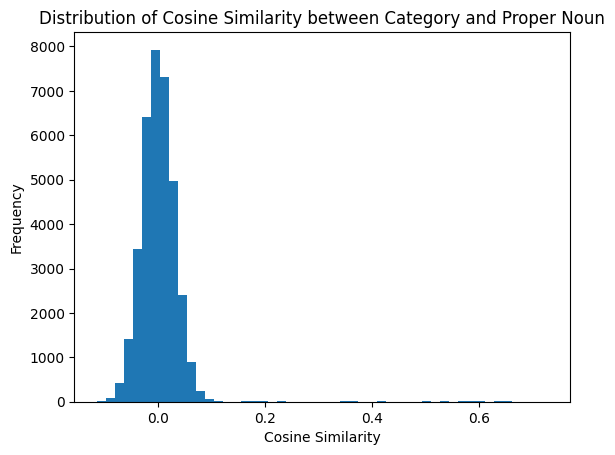

In [43]:
# cosine_similarityの分布を表示
import matplotlib.pyplot as plt
plt.hist(whole_df['cosine_similarity_gemma3_1b_it'], bins=50)
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Cosine Similarity between Category and Proper Noun')
plt.show()

In [33]:
# -1.0~1.0の範囲で、0.1刻みのbinを作り、各binに何個入っているかを表で示す
import numpy as np
bins = list(np.arange(-1.0, 0.0, 0.1)) + list(np.arange(0.0, 1.1, 0.1))  # -1.0から1.0まで0.1刻みのbinを作成
bin_counts = pd.cut(whole_df['cosine_similarity_gemma3_1b_it'], bins=bins).value_counts().sort_index()
bin_counts_df = bin_counts.reset_index()
bin_counts_df.columns = ['Cosine Similarity Range', 'Count']
bin_counts_df

,Cosine Similarity Range,Count
0,"(-1.0, -0.9]",0
1,"(-0.9, -0.8]",0
2,"(-0.8, -0.7]",0
3,"(-0.7, -0.6]",0
4,"(-0.6, -0.5]",0
5,"(-0.5, -0.4]",0
6,"(-0.4, -0.3]",0
7,"(-0.3, -0.2]",0
8,"(-0.2, -0.1]",6
9,"(-0.1, 0.0]",18132


In [ ]:
# 各binに何個入っているかを表で示す
bin_counts = pd.cut(whole_df['cosine_similarity_gemma3_1b_it'], bins=10).value_counts().sort_index()
bin_counts_df = bin_counts.reset_index()
bin_counts_df.columns = ['Cosine Similarity Range', 'Count']
bin_counts_df

,Cosine Similarity Range,Count
0,"(-0.116, -0.0305]",5345
1,"(-0.0305, 0.0538]",29033
2,"(0.0538, 0.138]",1218
3,"(0.138, 0.222]",24
4,"(0.222, 0.307]",17
5,"(0.307, 0.391]",20
6,"(0.391, 0.475]",26
7,"(0.475, 0.559]",23
8,"(0.559, 0.644]",39
9,"(0.644, 0.728]",17


In [34]:
whole_df.head()

,qid,label,class_label,class_qid,cosine_similarity_gemma3_1b_it
0,Q379764,lactase,enzyme,Q8047,0.002698
1,Q416589,maltase,enzyme,Q8047,-0.055105
2,Q10891385,Sucrose alpha-glucosidase,enzyme,Q8047,0.032907
3,Q5332143,Ecarin,enzyme,Q8047,-0.061189
4,Q7811495,Tobacco acid pyrophosphatase,enzyme,Q8047,0.006395


### 0.0~1.0の範囲で、0.1刻みのbinを作り、各binに含まれるclass_labelの数を表で示す

In [35]:

bins = list(np.arange(0.0, 1.1, 0.1))  # -1.0から1.0まで0.1刻みのbinを作成
# 0.0~1.0の範囲で、0.1刻みのbinを作り、各binに含まれるclass_labelの数を表で示す
bin_counts = pd.cut(whole_df['cosine_similarity_gemma3_1b_it'], bins=bins).value_counts().sort_index()
bin_counts_df = bin_counts.reset_index()
bin_counts_df.columns = ['Cosine Similarity Range', 'Count']
bin_counts_df

,Cosine Similarity Range,Count
0,"(0.0, 0.1]",17431
1,"(0.1, 0.2]",44
2,"(0.2, 0.3]",23
3,"(0.3, 0.4]",22
4,"(0.4, 0.5]",36
5,"(0.5, 0.6]",36
6,"(0.6, 0.7]",28
7,"(0.7, 0.8]",4
8,"(0.8, 0.9]",0
9,"(0.9, 1.0]",0


In [37]:

df = whole_df.copy()  # 例としてwhole_dfを使用

# ① 0.0〜1.0 の bin を作成
bins = np.arange(0.0, 1.1, 0.1)

# ② bin に分類
df["cos_bin"] = pd.cut(
    df["cosine_similarity_gemma3_1b_it"],
    bins=bins,
    include_lowest=True
)

# ③ bin × class_label の件数を集計
result = (
    df.groupby(["cos_bin", "class_label"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

result

/tmp/ipykernel_895604/735376154.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["cos_bin", "class_label"])


class_label,Algorithm,Disease,Employer,EthnicGroup,Flag,Hormone,Media,MedicalSpecialty,Medicine,Mill,...,television show,top level domain,tower,train,tunnel,vein,weapon,written work,year,zoo
cos_bin,,,,,,,,,,,,,,,,,,,,,
"(-0.001, 0.1]",174,544,24,541,33,4,487,28,70,121,...,459,263,463,57,408,16,30,409,286,196
"(0.1, 0.2]",0,2,0,0,0,0,2,0,0,0,...,0,0,4,0,0,0,0,0,0,0
"(0.2, 0.3]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"(0.3, 0.4]",0,0,0,1,1,0,0,0,0,0,...,0,0,2,0,0,1,0,0,0,0
"(0.4, 0.5]",0,0,0,0,2,0,0,0,0,4,...,0,0,12,0,7,0,0,0,0,0
"(0.5, 0.6]",0,0,0,0,0,0,0,0,0,0,...,0,0,3,0,3,0,0,0,0,0
"(0.6, 0.7]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"(0.7, 0.8]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"(0.8, 0.9]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
print(result)

class_label    Algorithm  Disease  Employer  EthnicGroup  Flag  Hormone  \
cos_bin                                                                   
(-0.001, 0.1]        174      544        24          541    33        4   
(0.1, 0.2]             0        2         0            0     0        0   
(0.2, 0.3]             0        0         0            0     0        0   
(0.3, 0.4]             0        0         0            1     1        0   
(0.4, 0.5]             0        0         0            0     2        0   
(0.5, 0.6]             0        0         0            0     0        0   
(0.6, 0.7]             0        0         0            0     0        0   
(0.7, 0.8]             0        0         0            0     0        0   
(0.8, 0.9]             0        0         0            0     0        0   
(0.9, 1.0]             0        0         0            0     0        0   

class_label    Media  MedicalSpecialty  Medicine  Mill  ...  television show  \
cos_bin            

## word2vecで同様にcos類似度を計算し、分布を調べる
→model消しちゃったっぽい。やるなら.bzのダウンロードからやり直し

In [29]:
pwd

'/home/toko/project/EmbedNewConcept/data/dbpedia'

In [30]:

from wikipedia2vec import Wikipedia2Vec
from wikipedia2vec.dictionary import Entity, Word

model_path = os.path.join("../../enwiki_20180420_300d.pkl") #.bz2")  # 例：300d (bin)
w2v = Wikipedia2Vec.load(model_path)

FileNotFoundError: [Errno 2] No such file or directory: '../../enwiki_20180420_300d.pkl'